# Forecasting Daily Bike Rental Demand Using Time Series Analysis

PRCP-1018 | Time Series Forecasting Project

# Problem Statement

Bike sharing systems have transformed urban mobility by automating the entire rental process — from membership to return. With over 500 bike-sharing programs and 500,000+ bicycles worldwide, these systems generate rich data that can be used to predict demand.

**Task 1:** Prepare a complete data analysis report on the given data.

**Task 2:** Predict the **daily bike rental count** based on environmental and seasonal settings.

**Target Variable:** `cnt` — Total daily bike rentals (casual + registered users)

# 📁 Table of Contents

1. Import Libraries
2. Load & Understand Data
3. Basic checks
4. Exploratory Data Analysis (EDA)
5. Data Preprocessing
6. Time Series Setup
7. Stationarity Check (ADF Test)
8. Train Test Split
9. Model Building (AR, ARIMA, SARIMA, Prophet)
10. Model Comparison Report
11. Challenges Faced
12. Conclusion & Model Saving

# 1. 📦 Import Libraries

We import all required libraries upfront. Explicit imports (no wildcards) are best practice for production-quality code — they make dependencies transparent and avoid namespace collisions.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 2. 📊 Load & Understand Data

We load the dataset and run basic checks to understand shape, data types, and get a first look at the data.

## Why `day.csv` and not `hour.csv`?
The dataset contains two files:
- `day.csv` — daily aggregated rental data (731 rows)
- `hour.csv` — hourly rental data (17,379 rows)

The problem statement asks for **"prediction of daily bike rental count"**, so we use `day.csv` as our primary dataset. Using `hour.csv` would require aggregation that duplicates what `day.csv` already provides cleanly.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving PRCP-1018-BikeRental.zip to PRCP-1018-BikeRental (1).zip


In [ ]:
import zipfile
import os

with zipfile.ZipFile("/content/PRCP-1018-BikeRental.zip", "r") as z:
    z.extractall("data")

print(os.listdir("data"))

['Data']


In [ ]:
day_df = pd.read_csv('data/Data/day.csv')
day_df

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
726,727,2012-12-27,1,1,12,0,4,1,2,0.254167,0.226642,0.652917,0.350133,247,1867,2114
727,728,2012-12-28,1,1,12,0,5,1,2,0.253333,0.255046,0.590000,0.155471,644,2451,3095
728,729,2012-12-29,1,1,12,0,6,0,2,0.253333,0.242400,0.752917,0.124383,159,1182,1341
729,730,2012-12-30,1,1,12,0,0,0,1,0.255833,0.231700,0.483333,0.350754,364,1432,1796


## 3. Basic Checks

In [ ]:
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [ ]:
day_df.tail()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
726,727,2012-12-27,1,1,12,0,4,1,2,0.254167,0.226642,0.652917,0.350133,247,1867,2114
727,728,2012-12-28,1,1,12,0,5,1,2,0.253333,0.255046,0.590000,0.155471,644,2451,3095
728,729,2012-12-29,1,1,12,0,6,0,2,0.253333,0.242400,0.752917,0.124383,159,1182,1341
729,730,2012-12-30,1,1,12,0,0,0,1,0.255833,0.231700,0.483333,0.350754,364,1432,1796
730,731,2012-12-31,1,1,12,0,1,1,2,0.215833,0.223487,0.577500,0.154846,439,2290,2729


In [ ]:
day_df.shape

(731, 16)

In [ ]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [ ]:
day_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


***📝 Observation from describe():***

- `cnt` ranges from 22 to 8714 — high variance in daily rentals reflects seasonal and weather effects
- `temp` and `atemp` are normalized between 0 and 1 (formula in dataset documentation)
- `casual` and `registered` are sub-components of `cnt` — must be dropped to avoid **data leakage**
- `instant` is just a row index — not useful for modeling
- `dteday` is object type — needs conversion to datetime for time series analysis
- `atemp` has 0.99 correlation with `temp` — one must be dropped to avoid **multicollinearity**

# 4. 🔍 Exploratory Data Analysis (EDA)

### 4.1 Univariate Analysis

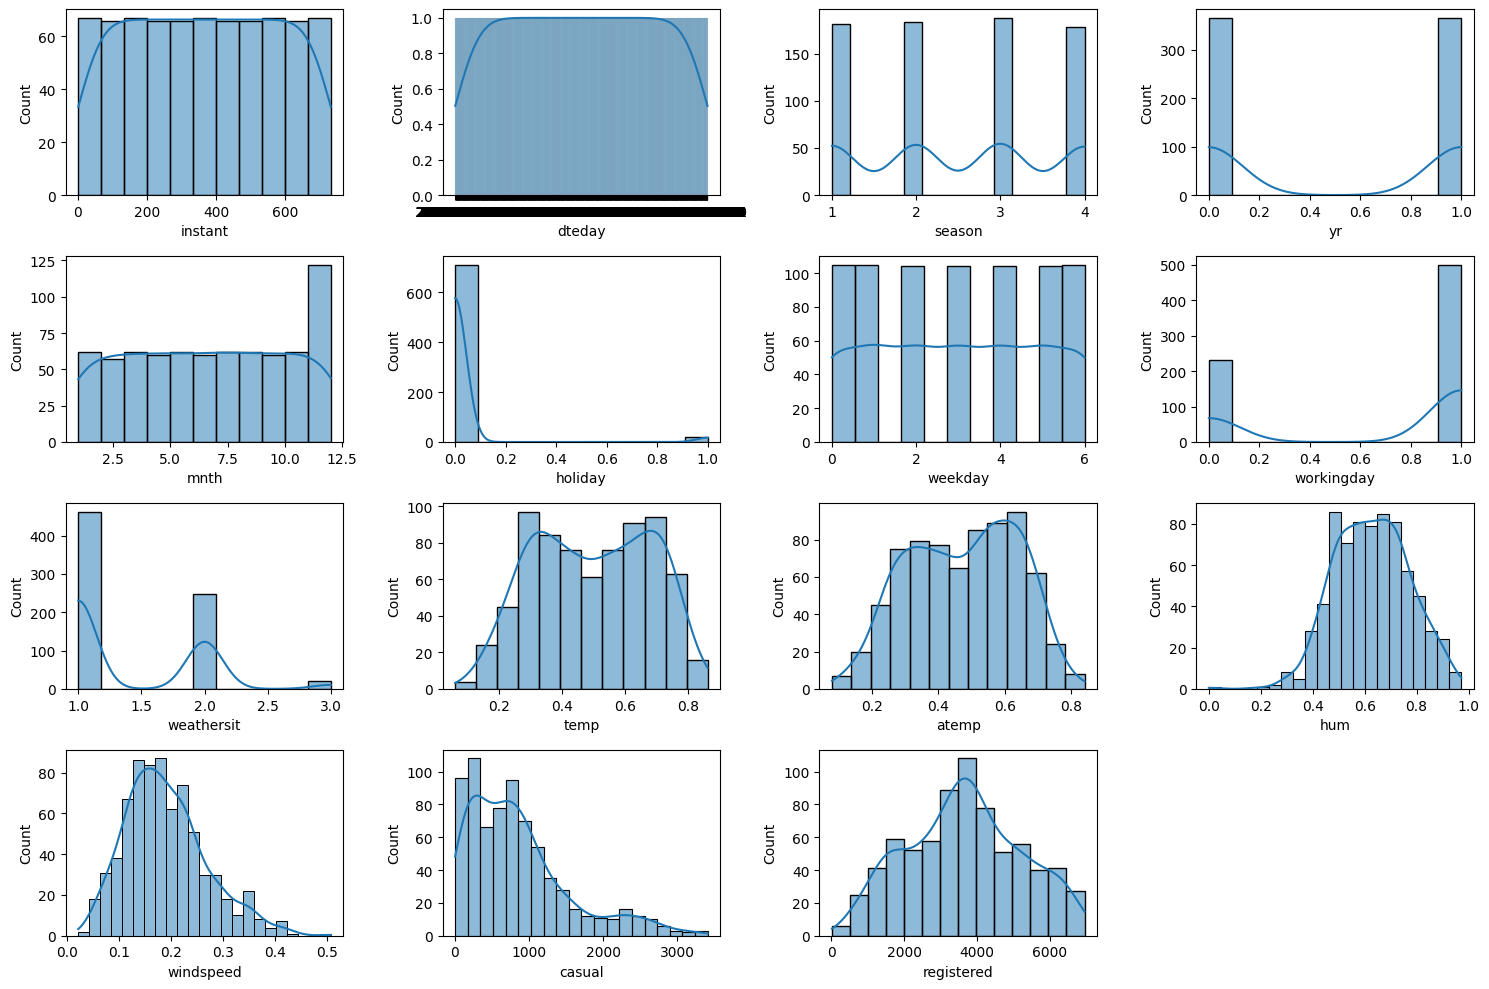

In [ ]:
plt.figure(figsize=(15,10))
pos=1
for i in day_df.columns[:-1]:
  plt.subplot(4,4,pos)
  sns.histplot(x=day_df[i],kde=True)
  pos+=1
plt.tight_layout()
plt.show()


### 4.2 Multivariate Analysis — Correlation Heatmap

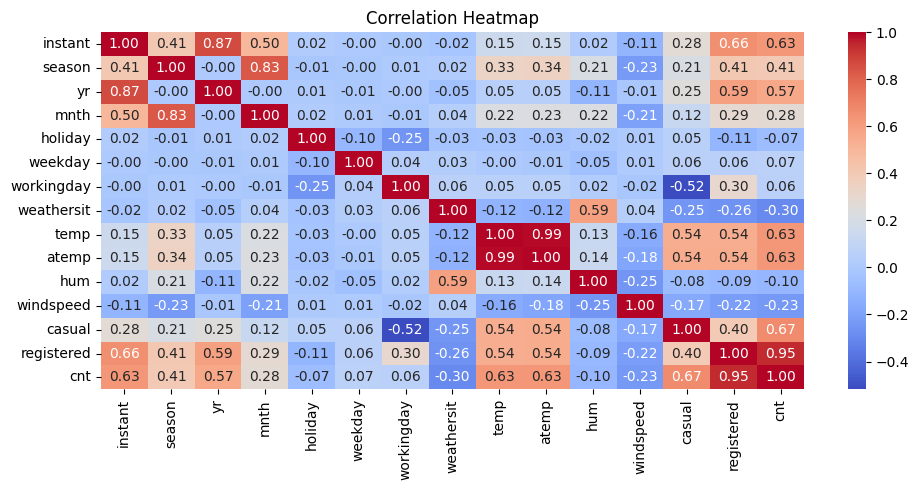

In [ ]:
plt.figure(figsize=(10,5))
sns.heatmap(day_df.corr(numeric_only=True),annot=True,fmt='.2f',cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

### 4.3 Bivariate Analysis — Top Features vs cnt

***Bivariate Analysis — Continuous Features vs cnt***

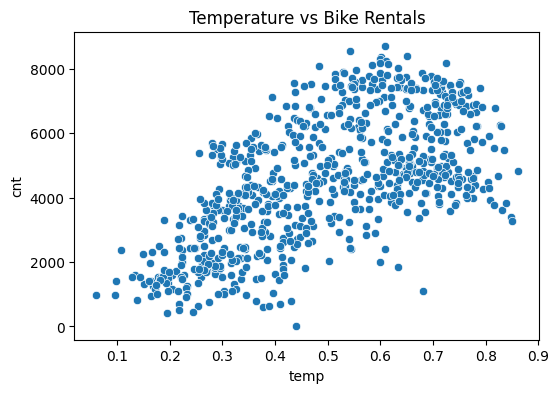

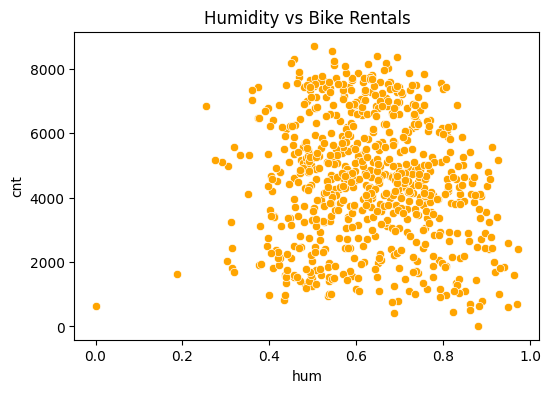

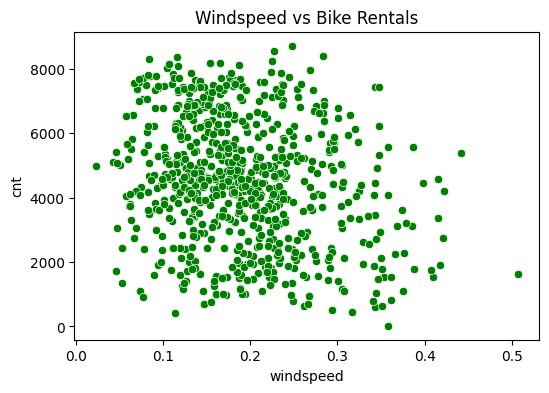

In [ ]:
# 1. Temperature vs cnt
plt.figure(figsize=(6,4))
sns.scatterplot(x='temp', y='cnt', data=day_df)
plt.title("Temperature vs Bike Rentals")
plt.show()

# 2. Humidity vs cnt
plt.figure(figsize=(6,4))
sns.scatterplot(x='hum', y='cnt', data=day_df, color='orange')
plt.title("Humidity vs Bike Rentals")
plt.show()

# 3. Windspeed vs cnt
plt.figure(figsize=(6,4))
sns.scatterplot(x='windspeed', y='cnt', data=day_df, color='green')
plt.title("Windspeed vs Bike Rentals")
plt.show()

***Bivariate Analysis — Categorical Features vs cnt***

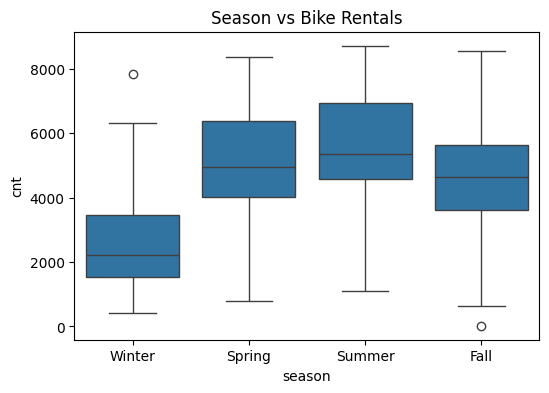

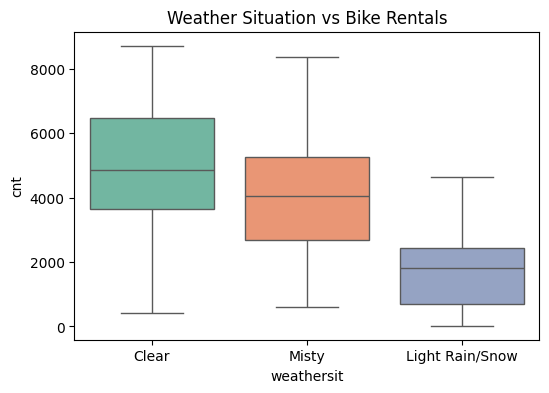

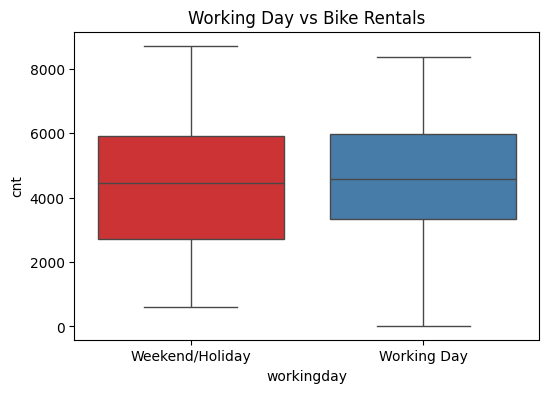

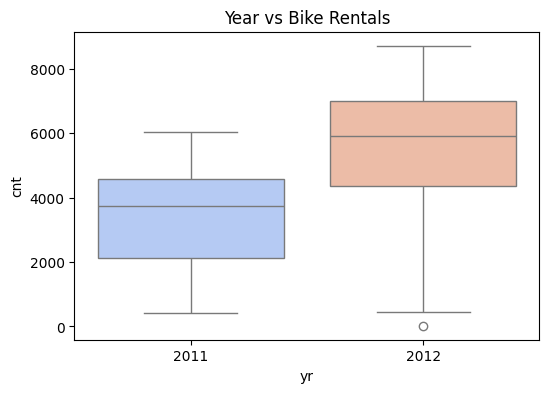

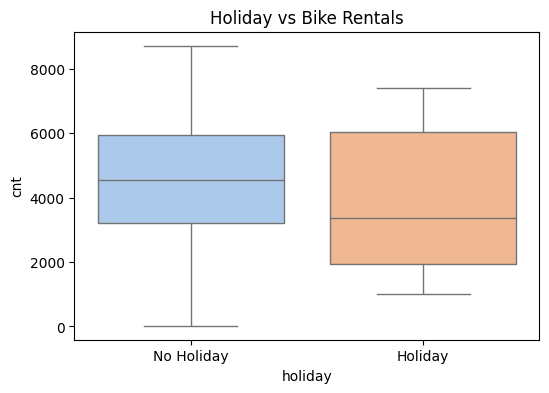

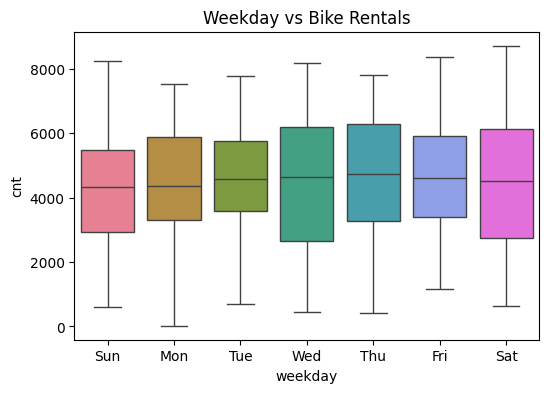

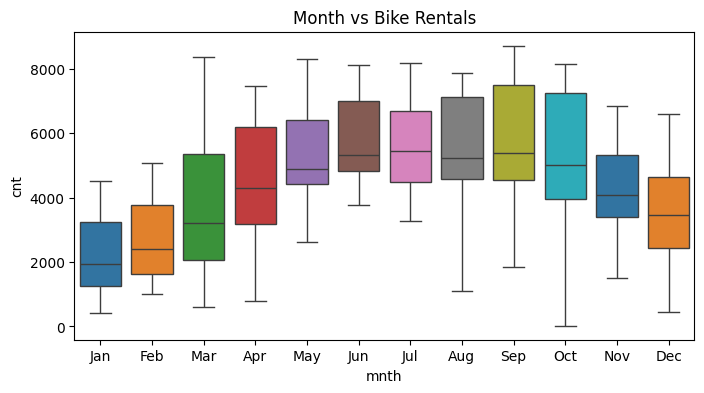

In [ ]:
# Season
plt.figure(figsize=(6,4))
sns.boxplot(x='season', y='cnt', data=day_df)
plt.xticks([0,1,2,3],['Winter','Spring','Summer','Fall'])
plt.title("Season vs Bike Rentals")
plt.show()

# Weather situation
plt.figure(figsize=(6,4))
sns.boxplot(x='weathersit', y='cnt', data=day_df, palette='Set2')
plt.xticks([0,1,2], ['Clear','Misty','Light Rain/Snow'])
plt.title("Weather Situation vs Bike Rentals")
plt.show()

# Workingday
plt.figure(figsize=(6,4))
sns.boxplot(x='workingday', y='cnt', data=day_df, palette='Set1')
plt.xticks([0,1], ['Weekend/Holiday','Working Day'])
plt.title("Working Day vs Bike Rentals")
plt.show()

# Year
plt.figure(figsize=(6,4))
sns.boxplot(x='yr', y='cnt', data=day_df, palette='coolwarm')
plt.xticks([0,1], ['2011','2012'])
plt.title("Year vs Bike Rentals")
plt.show()

# Holiday
plt.figure(figsize=(6,4))
sns.boxplot(x='holiday', y='cnt', data=day_df, palette='pastel')
plt.xticks([0,1], ['No Holiday','Holiday'])
plt.title("Holiday vs Bike Rentals")
plt.show()

# Weekday
plt.figure(figsize=(6,4))
sns.boxplot(x='weekday', y='cnt', data=day_df, palette='husl')
plt.xticks([0,1,2,3,4,5,6], ['Sun','Mon','Tue','Wed','Thu','Fri','Sat'])
plt.title("Weekday vs Bike Rentals")
plt.show()

# Month
plt.figure(figsize=(8,4))
sns.boxplot(x='mnth', y='cnt', data=day_df, palette='tab10')
plt.xticks(range(12), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.title("Month vs Bike Rentals")
plt.show()

### 4.4 EDA Insights

**Univariate Insights**
- cnt is near-normally distributed → good for forecasting
- casual rentals are right-skewed → most days have low casual usage
- windspeed has a few high-value outliers
- Most records are non-holidays (expected)
- Seasonal and weather categories are fairly balanced

**Bivariate Insights**

- Temperature: Clear positive trend — rentals increase as temperature rises (peak ~0.6–0.8 normalized)
- Humidity: Slight negative trend — very high humidity discourages cycling
- Windspeed: Negative trend — strong winds significantly reduce rentals
- Season: Summer and Fall have significantly higher rentals than Winter — strong seasonal pattern
- Weather: Clear weather drives the most rentals; Light Rain/Snow drops them sharply
- Year: 2012 rentals are noticeably higher than 2011 — system grew year-over-year
- Month: Peak months are May–September; January and February are the slowest
- Holiday: Slightly fewer rentals on holidays — commuter usage drops on non-working days

**Correlation Insights**
- Higher temperature        → more rentals
- High humidity             → slightly fewer rentals
- Strong wind               → fewer rentals
- Best seasons : Summer, Fall | Worst: Winter
- Clear weather → max rentals | Rain/snow → lowest demand
- 2012 >> 2011 in total rentals (significant YoY growth)
- Peak months  : May – September
- Holidays     → slightly lower rental activity

**Time Series Insights**
- Strong seasonal + yearly trends present
- Series is non-stationary → first-order differencing applied
- ACF & PACF used to identify lag structure for ARIMA
- Prophet outperformed SARIMA on trend & seasonality
  (advantage likely due to small dataset size)

**Key Takeaway**  
Bike rental demand is primarily driven by:
  1. Temperature
  2. Weather conditions
  3. Seasonality (Summer/Fall peak, May–Sep months)
  4. Yearly growth trend


## 5. Data Preprocessing

### 5.1 Missing Values & Duplicates

In [ ]:
missing = day_df.isnull().sum()
print("Missing values per column:")
print(missing)
print("\nTotal missing values:", missing.sum())
print("No missing values found." if missing.sum() == 0 else "Missing values exist — handle before proceeding.")

Missing values per column:
instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

Total missing values: 0
No missing values found.


In [ ]:
print("Duplicates:", day_df.duplicated().sum())

Duplicates: 0


***📝 Observation:***

- No NaN values and no duplicate rows — dataset is clean
- Unlike many datasets, there are no hidden zeros representing missing values here
- Data quality is excellent — we can proceed directly to outlier analysis

***Outlier Detection***

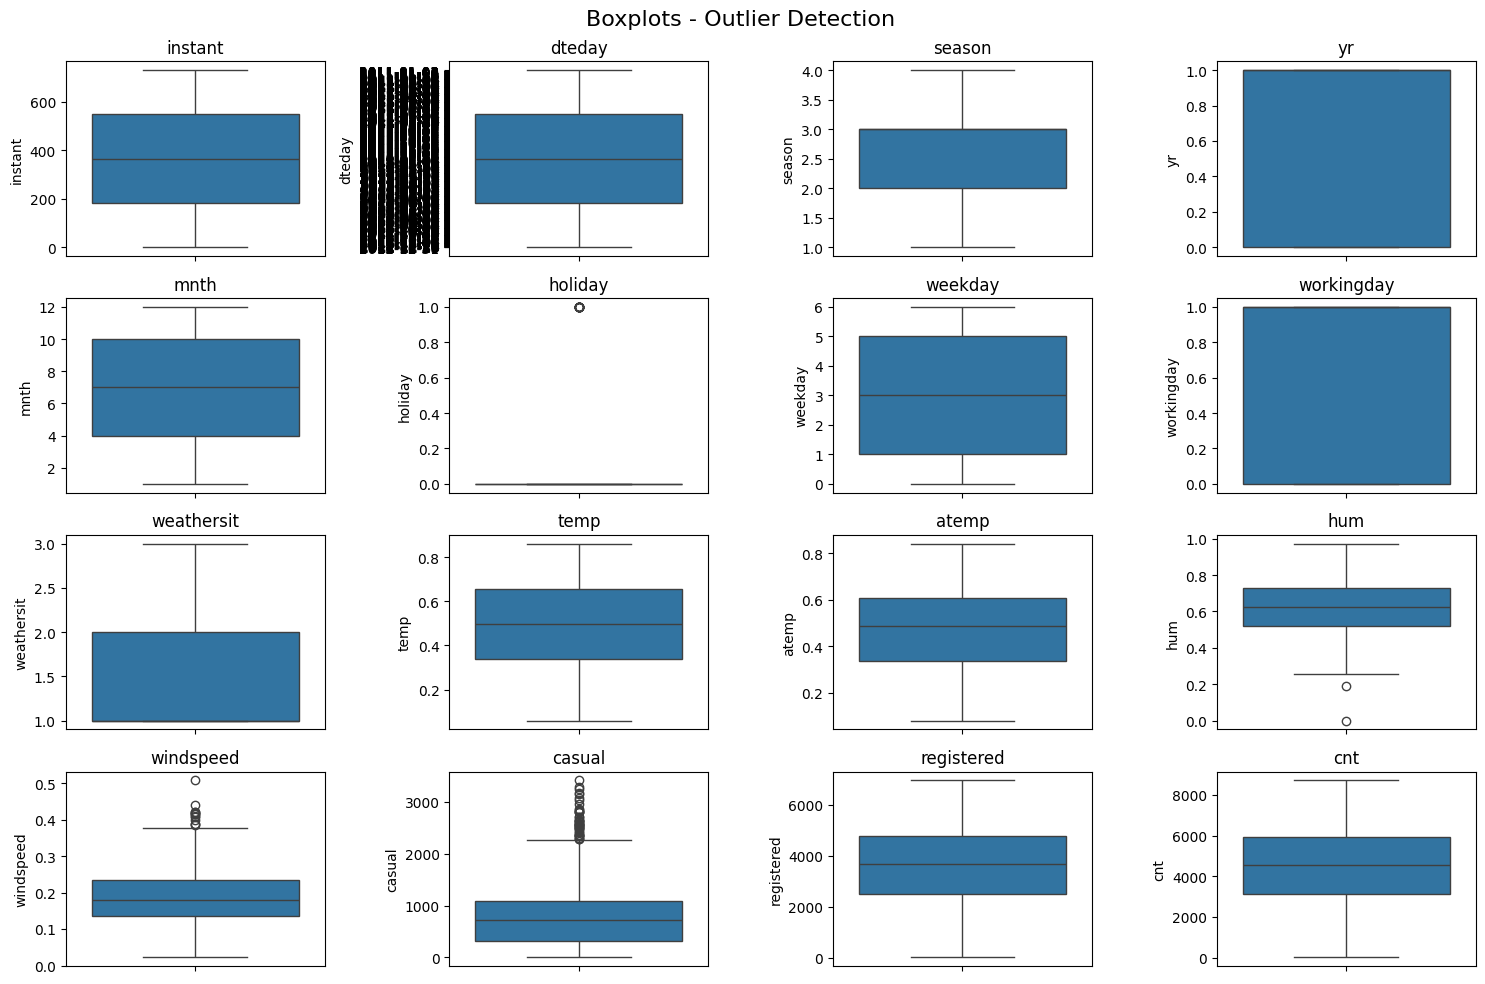

In [ ]:
plt.figure(figsize=(15,10))
pos=1
for i in day_df.columns:
    plt.subplot(4,4,pos)
    sns.boxplot(y=day_df[i])
    plt.title(i)
    pos+=1
plt.suptitle('Boxplots - Outlier Detection', fontsize=16)
plt.tight_layout()
plt.show()

***📝 Outlier Observation:***

| Column | Outliers | Decision |
|--------|----------|----------|
| `windspeed` | 13 | ✅ Cap using IQR — extreme values skew the distribution |
| `holiday` | 21 | ✅ Keep — binary column, boxplot flags 1s as outliers because holidays are rare |
| `hum` | 2 | ✅ Keep — only 2 rows, genuinely low humidity days |
| `cnt` | 0 | ✅ Perfect — target variable is clean |
| `casual` | 44 | ✅ Ignore — not used in our time series model |

***Outlier Treatment — Windspeed IQR Capping***

In [ ]:
Q1=day_df['windspeed'].quantile(0.25)
Q3=day_df['windspeed'].quantile(0.75)
IQR=Q3-Q1
day_df['windspeed'] = day_df['windspeed'].clip(lower=Q1 - 1.5*IQR, upper=Q3 + 1.5*IQR)

print(day_df['windspeed'].describe())

count    731.000000
mean       0.189846
std        0.075644
min        0.022392
25%        0.134950
50%        0.180975
75%        0.233214
max        0.380611
Name: windspeed, dtype: float64


***Skewness Check***

In [ ]:
print("cnt skewness:", day_df['cnt'].skew())

cnt skewness: -0.04735278011900183


***Skewness Check:***

- `cnt` skewness = -0.047 → Almost perfectly normal
- No log transformation required on the target variable
- This is ideal for time series modeling — the target does not need any transformation

# 6. 📈 Time Series Setup

For time series forecasting, we work with just `dteday` (as the date index) and `cnt` (as the target). We use `.copy()` to create an independent copy — protecting the original `day_df` from unintended modifications.

**Why `.copy()`?** Without it, modifying `ts_df` would also modify `day_df` due to shared memory references.

In [ ]:
ts_df = day_df[['dteday', 'cnt']].copy()
ts_df['dteday'] = pd.to_datetime(ts_df['dteday'])
ts_df = ts_df.set_index('dteday')
ts_df = ts_df.asfreq('D')

print("Shape:", ts_df.shape)
print("\nFirst 5 rows:\n", ts_df.head())
print("\nLast 5 rows:\n", ts_df.tail())

Shape: (731, 1)

First 5 rows:
              cnt
dteday          
2011-01-01   985
2011-01-02   801
2011-01-03  1349
2011-01-04  1562
2011-01-05  1600

Last 5 rows:
              cnt
dteday          
2012-12-27  2114
2012-12-28  3095
2012-12-29  1341
2012-12-30  1796
2012-12-31  2729


***Time Series Trend & Seasonality Plots***


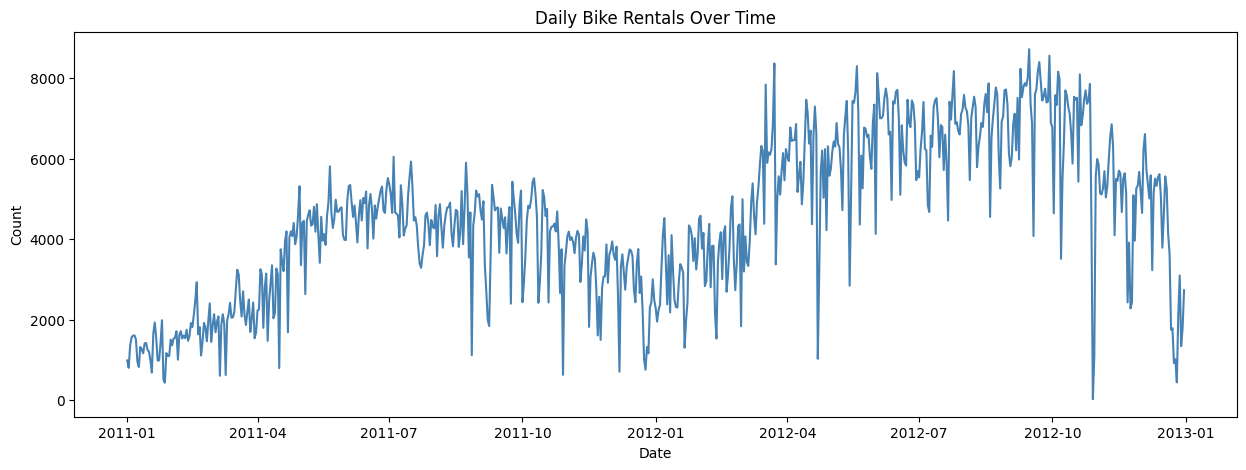

In [ ]:
# 1. Overall trend
plt.figure(figsize=(15,5))
plt.plot(ts_df, color='steelblue')
plt.title("Daily Bike Rentals Over Time")
plt.xlabel("Date")
plt.ylabel("Count")
plt.show()

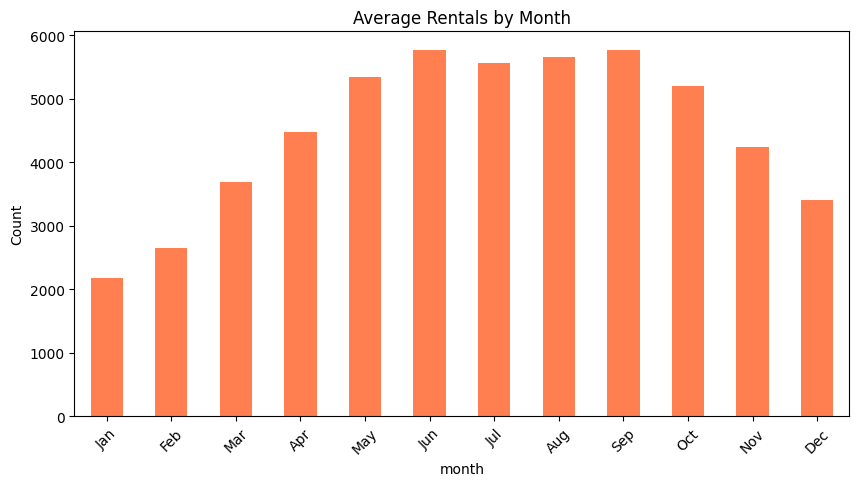

In [ ]:
# 2. Monthly average
ts_df['month'] = ts_df.index.month
ts_df['year'] = ts_df.index.year
plt.figure(figsize=(10,5))
ts_df.groupby('month')['cnt'].mean().plot(kind='bar', color='coral')
plt.xticks(range(12), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], rotation=45)
plt.title("Average Rentals by Month")
plt.ylabel("Count")
plt.show()


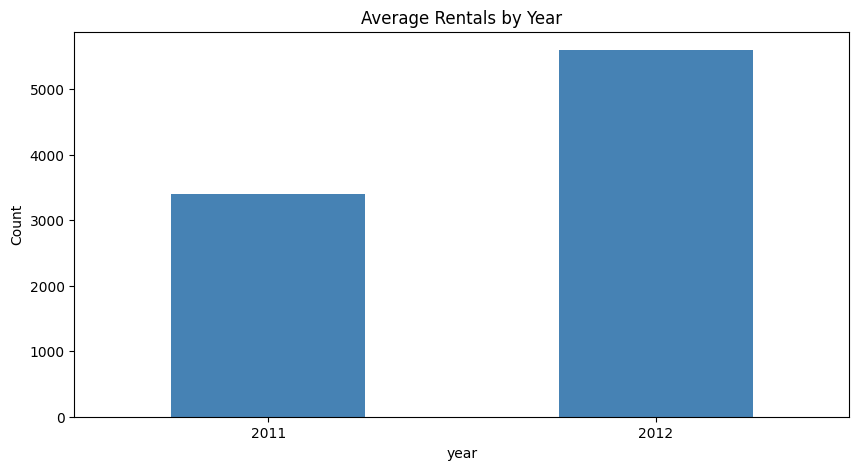

In [ ]:
# 3. Year wise comparison
plt.figure(figsize=(10,5))
ts_df.groupby('year')['cnt'].mean().plot(kind='bar', color='steelblue')
plt.xticks([0,1], ['2011','2012'], rotation=0)
plt.title("Average Rentals by Year")
plt.ylabel("Count")
plt.show()

***Time Series EDA — Observations:***

- Clear **upward trend** from 2011 to 2012 — the bike sharing system grew significantly year-over-year
- Strong **seasonal pattern** — peak in summer (Jun–Sep), trough in winter (Dec–Feb)
- 2012 monthly averages are consistently higher than 2011 across all months
- These patterns confirm we need a model that handles both **trend and seasonality**

# 7. 🔬 Stationarity Check (ADF Test)

Time series models like ARIMA and SARIMA require **stationary data** — meaning constant mean and variance over time. We use the **Augmented Dickey-Fuller (ADF) Test** to check this.

- **p-value ≤ 0.05** → Stationary ✅ (reject null hypothesis of unit root)
- **p-value > 0.05** → Non-Stationary ❌ (differencing needed)

<Figure size 1000x400 with 0 Axes>

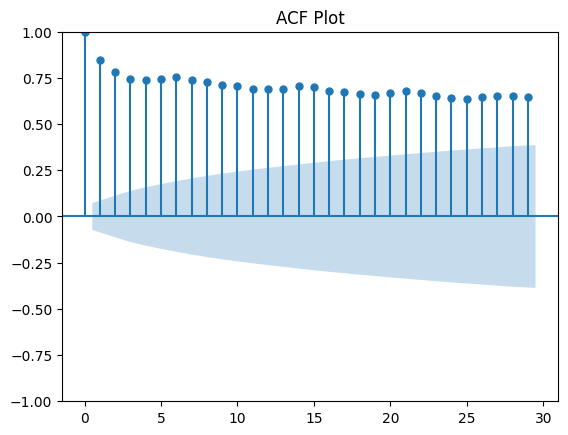

<Figure size 1000x400 with 0 Axes>

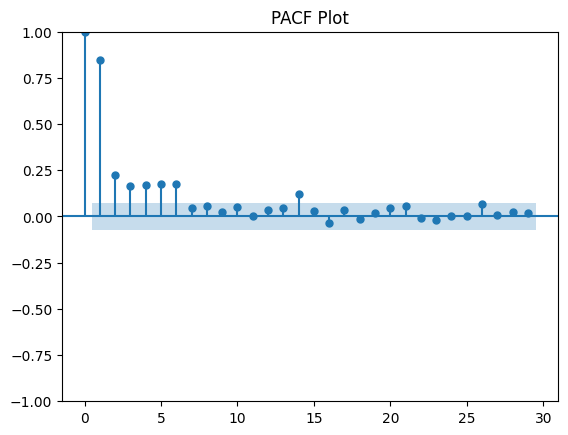

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ACF Plot(Lag → Total Correlation)
plt.figure(figsize=(10,4))
plot_acf(ts_df['cnt'])
plt.title("ACF Plot")
plt.show()

# PACF Plot(Lag → Direct Correlation)
plt.figure(figsize=(10,4))
plot_pacf(ts_df['cnt'])
plt.title("PACF Plot")
plt.show()

In [ ]:
# ADF Test
from statsmodels.tsa.stattools import adfuller
dftest = adfuller(ts_df['cnt'])
print('1. ADF Statistic:', dftest[0]) #by default we have to take 0, 1 , like that
print('2. P-Value:', dftest[1]) #statistical way-- implies non stationary

if dftest[1] <= 0.05:
    print("Stationary")
else:
    print("Non-Stationary")

1. ADF Statistic: -1.8774481444374291
2. P-Value: 0.3427434403392198
Non-Stationary


### Step 7.1 — Differencing to achieve Stationarity

Since the series is Non-Stationary, we apply **1st order differencing** — subtracting the previous day's value from the current day. This removes the trend and makes the series stationary. `.dropna()` removes the first row which becomes NaN after differencing.

In [ ]:
#differencing
ts_df1 = ts_df['cnt'].diff(periods=1).dropna()
print("Shape after differencing:", ts_df1.shape)

Shape after differencing: (730,)


<Figure size 1000x400 with 0 Axes>

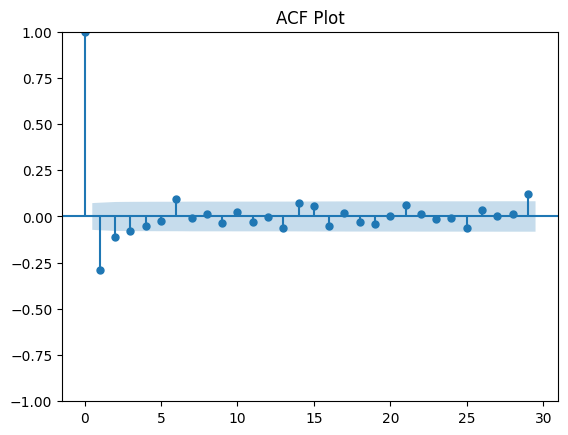

<Figure size 1000x400 with 0 Axes>

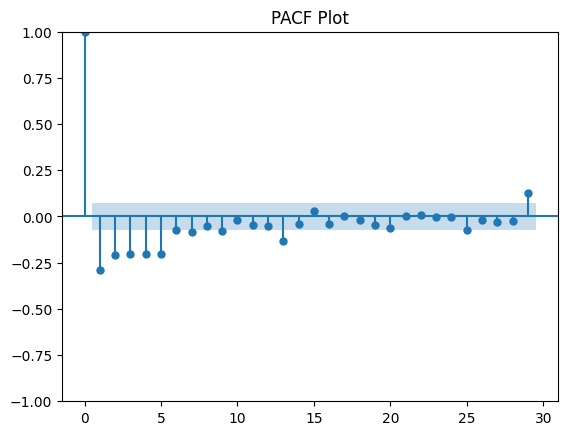

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ACF Plot(to calculate q)
plt.figure(figsize=(10,4))
plot_acf(ts_df1)
plt.title("ACF Plot")
plt.show()

# PACF Plot(to calculate p)
plt.figure(figsize=(10,4))
plot_pacf(ts_df1)
plt.title("PACF Plot")
plt.show()

In [ ]:
# ADF Test
from statsmodels.tsa.stattools import adfuller
df1test = adfuller(ts_df1)
print('1. ADF Statistic:', df1test[0]) #by default we have to take 0, 1 , like that
print('2. P-Value:', df1test[1]) #statistical way-- implies non stationary

if df1test[1] <= 0.05:
    print("Stationary")
else:
    print("Non-Stationary")

1. ADF Statistic: -11.778809074151864
2. P-Value: 1.0467797548020789e-21
Stationary


***📝 ACF/PACF Reading & Final SARIMA Parameters:***

| Parameter | Source | Value | Reasoning |
|-----------|--------|-------|-----------|
| **p** | PACF | 4 | Lags 1–4 fall outside the blue confidence band |
| **d** | ADF Test | 1 | 1st differencing confirmed stationarity (p-value < 0.05) |
| **q** | ACF | 1 | Lag 1 falls outside the blue confidence band |

**Final Parameters: SARIMA(4, 1, 1)**

# 8. ✂️ Train Test Split

For time series, we **never use random splitting** — it would break the temporal order and cause data leakage. We use an **80/20 chronological split** — train on the past, test on the most recent data.

- **Tip:** Unlike classification where we use `stratify=y`, time series must always split by time order.

In [ ]:
# 80-20 split by date order
split = int(len(ts_df) * 0.8)  # 80% of 731 = 584

train = ts_df['cnt'][:split]
test = ts_df['cnt'][split:]

print("Train size:", len(train))
print("Test size:", len(test))
print("Train period:", train.index[0], "to", train.index[-1])
print("Test period:", test.index[0], "to", test.index[-1])

Train size: 584
Test size: 147
Train period: 2011-01-01 00:00:00 to 2012-08-06 00:00:00
Test period: 2012-08-07 00:00:00 to 2012-12-31 00:00:00


***📝 Train-Test Split:***

- 80% training (584 days: Jan 2011 → Aug 2012), 20% testing (147 days: Aug 2012 → Dec 2012)
- Chronological split is mandatory for time series — random splitting would leak future information into training
- Test period covers the last 5 months of 2012 — a good range to evaluate seasonal predictions

# 9. 🤖 Model Building & Evaluation

We train four models of increasing complexity and compare their performance on the held-out test set.

**Metrics used:**
- **RMSE** (Root Mean Squared Error) — penalizes large errors more heavily
- **MAE** (Mean Absolute Error) — average absolute error in original units (number of bikes)
- **R²** — proportion of variance explained (1.0 = perfect; 0 = no better than mean)

## 9.1 AR Model (Baseline)

AutoRegressive model — predicts using only past values of the series. This is our **simplest baseline** — all other models must beat this to justify their complexity.

In [ ]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
from statsmodels.tsa.ar_model import AutoReg, ar_select_order

# Auto select best lags
mod = ar_select_order(train, maxlag=15, glob=True)
print("Best lags:", mod.ar_lags)

Best lags: [1, 6, 8, 11, 15]


In [ ]:
# Build AR model with selected lags
ar_model = AutoReg(train, lags=mod.ar_lags)
ar_model_fit = ar_model.fit()

In [ ]:
# Predict
ar_pred = ar_model_fit.predict(start=len(train), end=len(train)+len(test)-1)


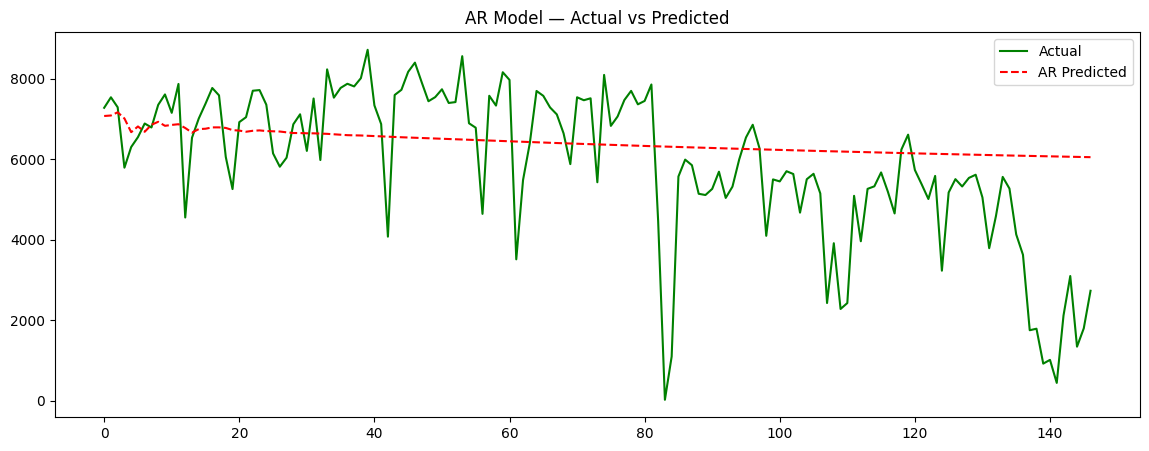

In [ ]:
# Plot
plt.figure(figsize=(14,5))
plt.plot(test.values, label='Actual', color='green')
plt.plot(ar_pred.values, label='AR Predicted', color='red', linestyle='--')
plt.title("AR Model — Actual vs Predicted")
plt.legend()
plt.show()

In [ ]:
# Metrics
mae = mean_absolute_error(test, ar_pred)
mse = mean_squared_error(test, ar_pred)
rmse = np.sqrt(mse)
r2 = r2_score(test, ar_pred)
print('MAE:', round(mae,2))
print('MSE:', round(mse,2))
print('RMSE:', round(rmse,2))
print('R2:', round(r2,2))

MAE: 1322.05
MSE: 3261794.97
RMSE: 1806.04
R2: 0.07


***📝 AR Model Results:***

- RMSE: 1806.04 | MAE: 1322.05 | R²: 0.07
- AR model performs poorly because it only uses past values and does not account for trend, seasonality, or external factors
- R² of 0.07 means the model explains only 7% of variance — barely better than predicting the mean
- This is our **baseline** — all other models should improve on this

## 9.2 ARIMA Model

ARIMA adds **Integrated** (differencing) and **Moving Average** components to AR. It handles trend but not seasonality.

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

# Build ARIMA with p=4, d=1, q=1
arima_model = ARIMA(train, order=(4,1,1)).fit()

In [ ]:
# Predict
arima_pred = arima_model.forecast(steps=len(test))
arima_pred.index = test.index

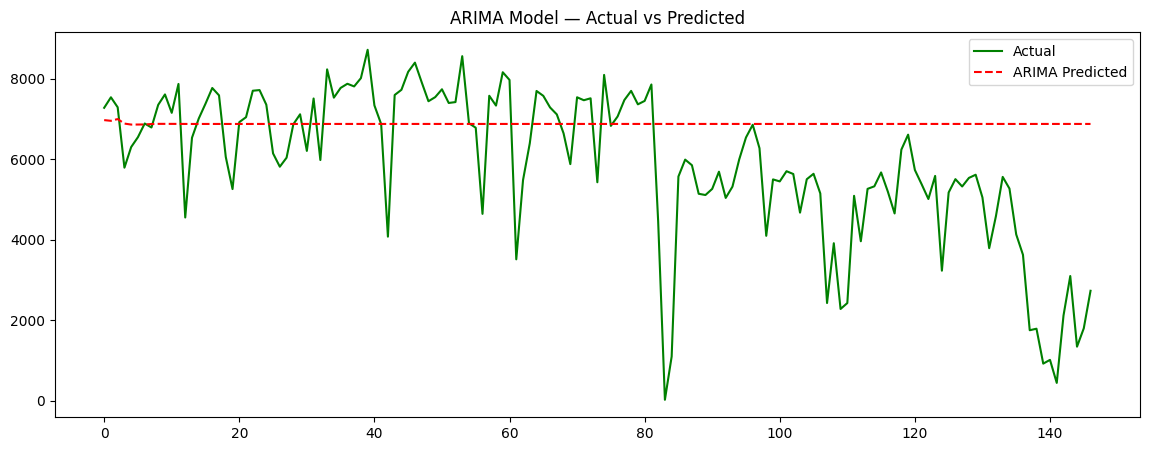

In [ ]:
# Plot
plt.figure(figsize=(14,5))
plt.plot(test.values, label='Actual', color='green')
plt.plot(arima_pred.values, label='ARIMA Predicted', color='red', linestyle='--')
plt.title("ARIMA Model — Actual vs Predicted")
plt.legend()
plt.show()

In [ ]:
# Metrics
mae = mean_absolute_error(test, arima_pred)
mse = mean_squared_error(test, arima_pred)
rmse = np.sqrt(mse)
r2 = r2_score(test, arima_pred)
print('MAE:', round(mae,2))
print('MSE:', round(mse,2))
print('RMSE:', round(rmse,2))
print('R2:', round(r2,2))

MAE: 1522.11
MSE: 4461816.25
RMSE: 2112.3
R2: -0.27


***📝 ARIMA Model Results:***

- RMSE: 2112.30 | MAE: 1522.11 | R²: -0.27
- ARIMA performs **worse** than AR — negative R² indicates the model is worse than predicting the mean
- Root cause: ARIMA does not handle the **strong seasonality** present in this dataset (summer vs winter patterns)
- The MA term (q=1) is not capturing the pattern well without seasonal components

## 9.3 SARIMA Model

Seasonal ARIMA — extends ARIMA with seasonal components (P, D, Q, s). We test two configurations to find the best setup.

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# SARIMA (p=4, d=1, q=1) x (P=1, D=1, Q=1, s=7) weekly seasonality
sarima_model = SARIMAX(train, order=(4,1,1), seasonal_order=(1,1,1,7)).fit(disp=False)


In [ ]:
# Predict
sarima_pred = sarima_model.forecast(steps=len(test))
sarima_pred.index = test.index

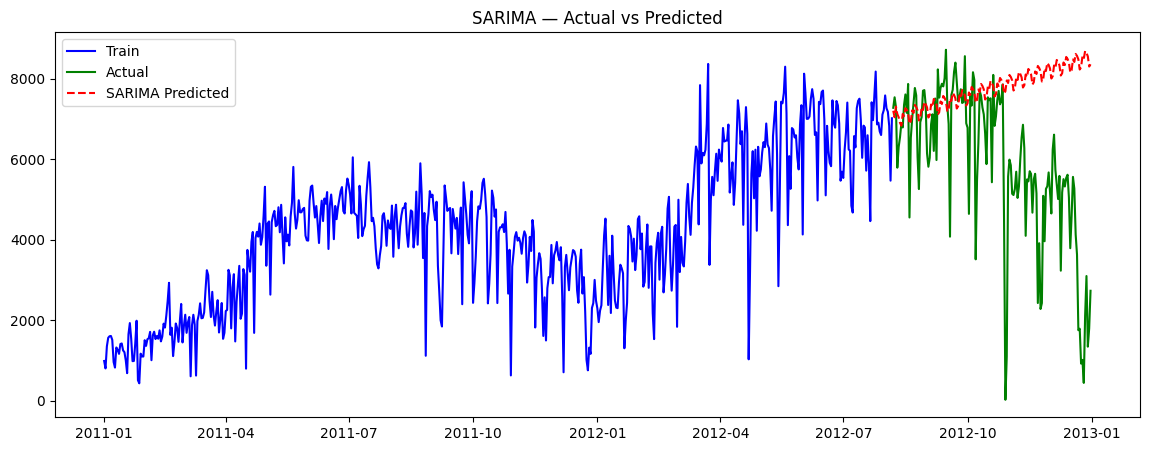

In [ ]:
# Plot
plt.figure(figsize=(14,5))
plt.plot(train.index, train.values, label='Train', color='blue')
plt.plot(test.index, test.values, label='Actual', color='green')
plt.plot(test.index, sarima_pred.values, label='SARIMA Predicted', color='red', linestyle='--')
plt.title("SARIMA — Actual vs Predicted")
plt.legend()
plt.show()

In [ ]:
# Metrics
mae = mean_absolute_error(test, sarima_pred)
mse = mean_squared_error(test, sarima_pred)
rmse = np.sqrt(mse)
r2 = r2_score(test, sarima_pred)
print('MAE:', round(mae,2))
print('MSE:', round(mse,2))
print('RMSE:', round(rmse,2))
print('R2:', round(r2,2))

MAE: 2042.82
MSE: 8223928.26
RMSE: 2867.74
R2: -1.34


In [ ]:
# Simple SARIMA without seasonal
sarima_model2 = SARIMAX(train, order=(1,1,1)).fit(disp=False)

In [ ]:
# Predict
sarima_pred2 = sarima_model2.forecast(steps=len(test))
sarima_pred2.index = test.index

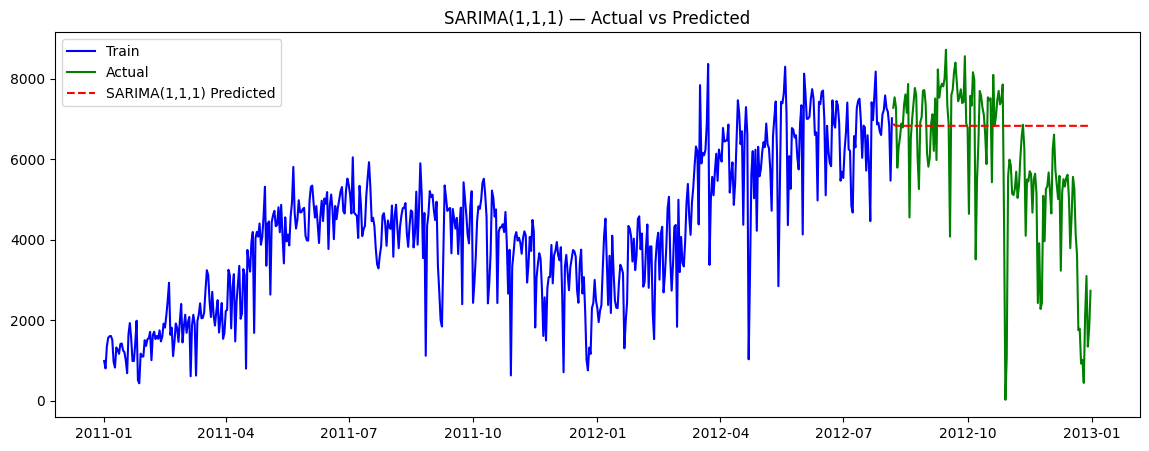

In [ ]:
# Plot
plt.figure(figsize=(14,5))
plt.plot(train.index, train.values, label='Train', color='blue')
plt.plot(test.index, test.values, label='Actual', color='green')
plt.plot(test.index, sarima_pred2.values, label='SARIMA(1,1,1) Predicted', color='red', linestyle='--')
plt.title("SARIMA(1,1,1) — Actual vs Predicted")
plt.legend()
plt.show()

In [ ]:
# Metrics
mae = mean_absolute_error(test, sarima_pred2)
mse = mean_squared_error(test, sarima_pred2)
rmse = np.sqrt(mse)
r2 = r2_score(test, sarima_pred2)
print('MAE:', round(mae,2))
print('MSE:', round(mse,2))
print('RMSE:', round(rmse,2))
print('R2:', round(r2,2))

MAE: 1514.71
MSE: 4373847.32
RMSE: 2091.37
R2: -0.24


***📝 SARIMA Model Results:***

- SARIMA(4,1,1)(1,1,1,7): RMSE 2867.74 | R² -1.34 — worst performer
- SARIMA(1,1,1): RMSE 2091.37 | R² -0.24 — slightly better but still poor
- **Root cause:** SARIMA requires large datasets (5+ years ideally) to learn seasonal patterns. Our dataset has only 731 rows (2 years) — insufficient for SARIMA to generalize well.
- The weekly seasonality parameter (s=7) adds too many parameters for this small dataset → overfitting

## 9.4 Prophet Model

Facebook Prophet is designed for business time series. It automatically handles trend, seasonality (daily/weekly/yearly), and holiday effects **without manual p,d,q tuning**.

In [ ]:
from prophet import Prophet

# Prophet needs columns named ds and y
train_prophet = pd.DataFrame({'ds': train.index, 'y': train.values})
test_prophet = pd.DataFrame({'ds': test.index, 'y': test.values})

In [ ]:
# Build and fit
prophet_model = Prophet(daily_seasonality=True, weekly_seasonality=True, yearly_seasonality=True)
prophet_model.fit(train_prophet)

In [ ]:
# Predict
future = prophet_model.make_future_dataframe(periods=len(test))
forecast = prophet_model.predict(future)

In [ ]:
# Get only test period predictions
prophet_pred = forecast[['ds','yhat']].tail(len(test))
prophet_pred = prophet_pred.set_index('ds')

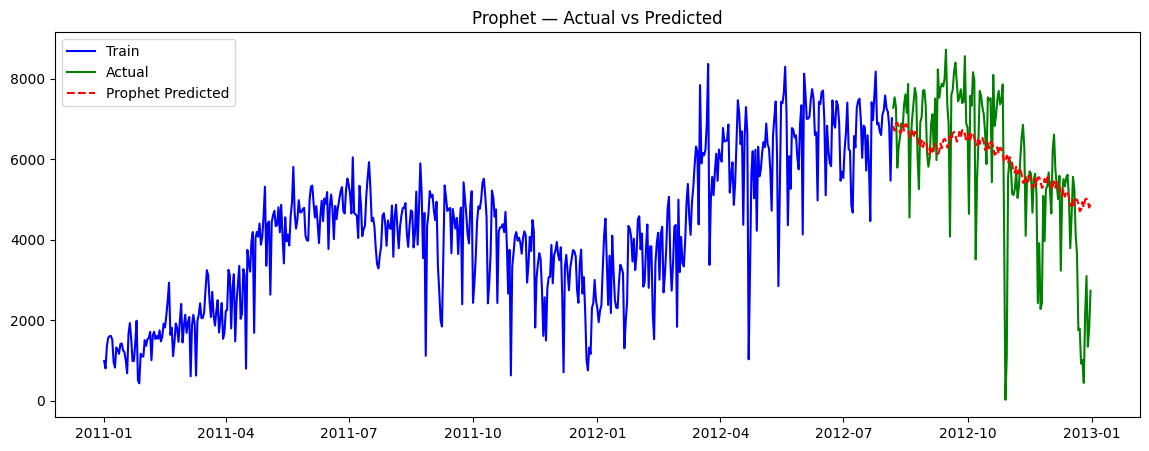

In [ ]:
# Plot
plt.figure(figsize=(14,5))
plt.plot(train.index, train.values, label='Train', color='blue')
plt.plot(test.index, test.values, label='Actual', color='green')
plt.plot(prophet_pred.index, prophet_pred['yhat'].values, label='Prophet Predicted', color='red', linestyle='--')
plt.title("Prophet — Actual vs Predicted")
plt.legend()
plt.show()

In [ ]:
# Metrics
mae = mean_absolute_error(test.values, prophet_pred['yhat'].values)
mse = mean_squared_error(test.values, prophet_pred['yhat'].values)
rmse = np.sqrt(mse)
r2 = r2_score(test.values, prophet_pred['yhat'].values)
print('MAE:', round(mae,2))
print('MSE:', round(mse,2))
print('RMSE:', round(rmse,2))
print('R2:', round(r2,2))

MAE: 1088.27
MSE: 2237090.1
RMSE: 1495.69
R2: 0.36


### Step 8.4.1 — Prophet with External Regressors (Improved)

We add `temp` as an external regressor since it has the highest correlation with `cnt` (0.63). External regressors let Prophet use real-world factors beyond just the date pattern.

MAE: 1055.06
MSE: 1974993.77
RMSE: 1405.34
R2: 0.44


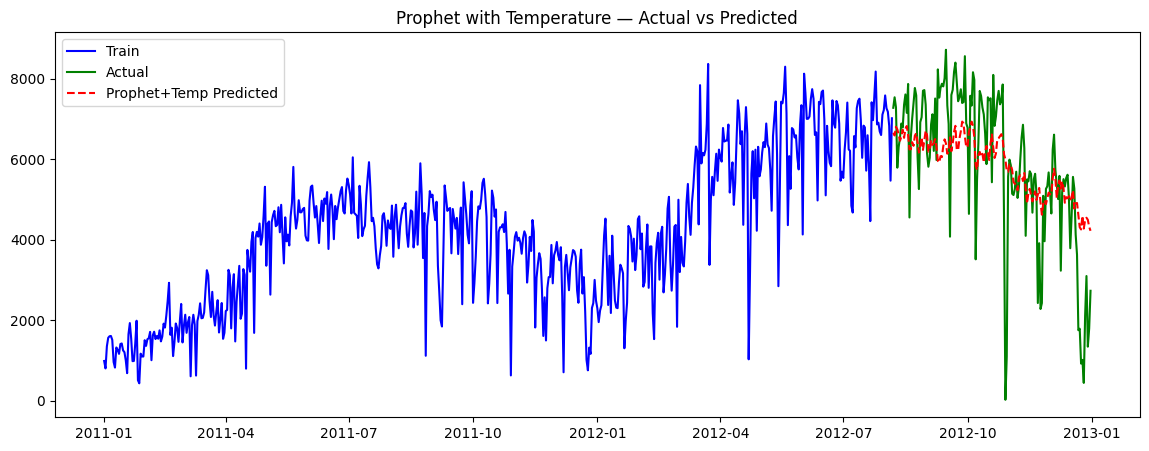

In [ ]:
# Prepare train and test with temperature
train_prophet2 = pd.DataFrame({
    'ds': train.index,
    'y': train.values,
    'temp': day_df['temp'][:split].values
})

test_prophet2 = pd.DataFrame({
    'ds': test.index,
    'y': test.values,
    'temp': day_df['temp'][split:].values
})

# Build Prophet with temp as regressor
prophet_model2 = Prophet(
    changepoint_prior_scale=0.5,
    seasonality_prior_scale=10,
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=True
)
prophet_model2.add_regressor('temp')
prophet_model2.fit(train_prophet2)

# Predict
future2 = test_prophet2[['ds','temp']]
forecast2 = prophet_model2.predict(future2)

# Metrics
mae = mean_absolute_error(test.values, forecast2['yhat'].values)
mse = mean_squared_error(test.values, forecast2['yhat'].values)
rmse = np.sqrt(mse)
r2 = r2_score(test.values, forecast2['yhat'].values)
print('MAE:', round(mae,2))
print('MSE:', round(mse,2))
print('RMSE:', round(rmse,2))
print('R2:', round(r2,2))

# Plot
plt.figure(figsize=(14,5))
plt.plot(train.index, train.values, label='Train', color='blue')
plt.plot(test.index, test.values, label='Actual', color='green')
plt.plot(test_prophet2['ds'].values, forecast2['yhat'].values,
         label='Prophet+Temp Predicted', color='red', linestyle='--')
plt.title("Prophet with Temperature — Actual vs Predicted")
plt.legend()
plt.show()

### Step 8.4.2 — Prophet with Multiple Regressors (Feature Experiments)

We systematically test adding more external regressors. **Key rule:** Only add regressors with correlation > 0.20 with the target.

MAE: 1278.97
MSE: 3166765.23
RMSE: 1779.54
R2: 0.1


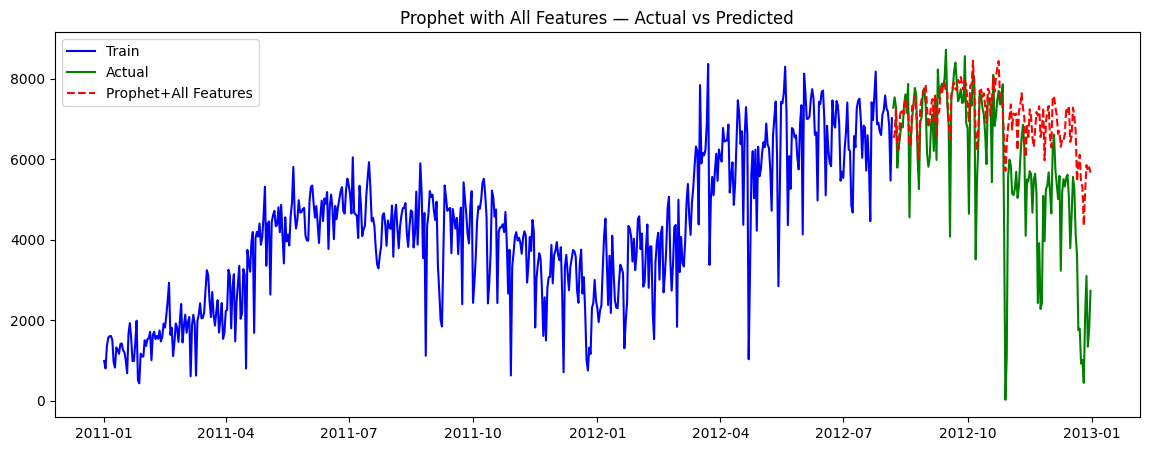

In [ ]:
# Prepare train and test with multiple regressors
train_prophet3 = pd.DataFrame({
    'ds': train.index,
    'y': train.values,
    'temp': day_df['temp'][:split].values,
    'hum': day_df['hum'][:split].values,
    'windspeed': day_df['windspeed'][:split].values,
    'season': day_df['season'][:split].values,
    'weathersit': day_df['weathersit'][:split].values,
    'workingday': day_df['workingday'][:split].values
})

test_prophet3 = pd.DataFrame({
    'ds': test.index,
    'y': test.values,
    'temp': day_df['temp'][split:].values,
    'hum': day_df['hum'][split:].values,
    'windspeed': day_df['windspeed'][split:].values,
    'season': day_df['season'][split:].values,
    'weathersit': day_df['weathersit'][split:].values,
    'workingday': day_df['workingday'][split:].values
})

# Build Prophet with all regressors
prophet_model3 = Prophet(
    changepoint_prior_scale=0.5,
    seasonality_prior_scale=10,
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=True
)

# Add all regressors
for col in ['temp', 'hum', 'windspeed', 'season', 'weathersit', 'workingday']:
    prophet_model3.add_regressor(col)

prophet_model3.fit(train_prophet3)

# Predict
future3 = test_prophet3[['ds','temp','hum','windspeed','season','weathersit','workingday']]
forecast3 = prophet_model3.predict(future3)

# Metrics
mae = mean_absolute_error(test.values, forecast3['yhat'].values)
mse = mean_squared_error(test.values, forecast3['yhat'].values)
rmse = np.sqrt(mse)
r2 = r2_score(test.values, forecast3['yhat'].values)
print('MAE:', round(mae,2))
print('MSE:', round(mse,2))
print('RMSE:', round(rmse,2))
print('R2:', round(r2,2))

# Plot
plt.figure(figsize=(14,5))
plt.plot(train.index, train.values, label='Train', color='blue')
plt.plot(test.index, test.values, label='Actual', color='green')
plt.plot(test_prophet3['ds'].values, forecast3['yhat'].values,
         label='Prophet+All Features', color='red', linestyle='--')
plt.title("Prophet with All Features — Actual vs Predicted")
plt.legend()
plt.show()

MAE: 1023.93
MSE: 1881104.06
RMSE: 1371.53
R2: 0.46


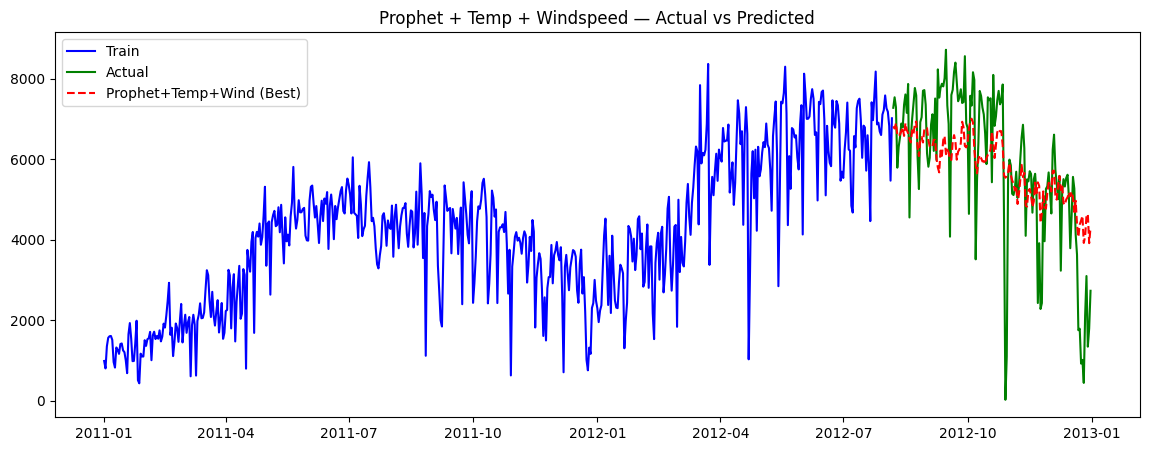

In [ ]:
# Only temp + windspeed (best external regressors)
train_prophet4 = pd.DataFrame({
    'ds': train.index,
    'y': train.values,
    'temp': day_df['temp'][:split].values,
    'windspeed': day_df['windspeed'][:split].values
})

test_prophet4 = pd.DataFrame({
    'ds': test.index,
    'y': test.values,
    'temp': day_df['temp'][split:].values,
    'windspeed': day_df['windspeed'][split:].values
})

prophet_model4 = Prophet(
    changepoint_prior_scale=0.5,
    seasonality_prior_scale=10,
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=True
)

prophet_model4.add_regressor('temp')
prophet_model4.add_regressor('windspeed')
prophet_model4.fit(train_prophet4)

# Predict
future4 = test_prophet4[['ds','temp','windspeed']]
forecast4 = prophet_model4.predict(future4)

# Metrics
mae = mean_absolute_error(test.values, forecast4['yhat'].values)
mse = mean_squared_error(test.values, forecast4['yhat'].values)
rmse = np.sqrt(mse)
r2 = r2_score(test.values, forecast4['yhat'].values)
print('MAE:', round(mae,2))
print('MSE:', round(mse,2))
print('RMSE:', round(rmse,2))
print('R2:', round(r2,2))

# Plot
plt.figure(figsize=(14,5))
plt.plot(train.index, train.values, label='Train', color='blue')
plt.plot(test.index, test.values, label='Actual', color='green')
plt.plot(test_prophet4['ds'].values, forecast4['yhat'].values,
         label='Prophet+Temp+Wind (Best)', color='red', linestyle='--')
plt.title("Prophet + Temp + Windspeed — Actual vs Predicted")
plt.legend()
plt.show()

MAE: 1079.86
MSE: 2495560.03
RMSE: 1579.73
R2: 0.29


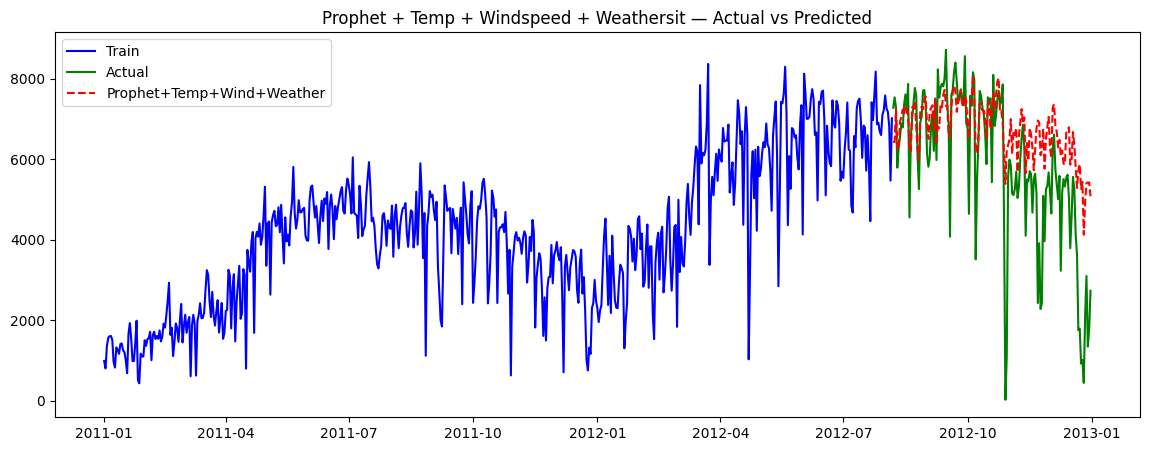

In [ ]:
# temp + windspeed + weathersit
train_prophet5 = pd.DataFrame({
    'ds': train.index,
    'y': train.values,
    'temp': day_df['temp'][:split].values,
    'windspeed': day_df['windspeed'][:split].values,
    'weathersit': day_df['weathersit'][:split].values
})

test_prophet5 = pd.DataFrame({
    'ds': test.index,
    'y': test.values,
    'temp': day_df['temp'][split:].values,
    'windspeed': day_df['windspeed'][split:].values,
    'weathersit': day_df['weathersit'][split:].values
})

prophet_model5 = Prophet(
    changepoint_prior_scale=0.5,
    seasonality_prior_scale=10,
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=True
)

prophet_model5.add_regressor('temp')
prophet_model5.add_regressor('windspeed')
prophet_model5.add_regressor('weathersit')
prophet_model5.fit(train_prophet5)

# Predict
future5 = test_prophet5[['ds','temp','windspeed','weathersit']]
forecast5 = prophet_model5.predict(future5)

# Metrics
mae = mean_absolute_error(test.values, forecast5['yhat'].values)
mse = mean_squared_error(test.values, forecast5['yhat'].values)
rmse = np.sqrt(mse)
r2 = r2_score(test.values, forecast5['yhat'].values)
print('MAE:', round(mae,2))
print('MSE:', round(mse,2))
print('RMSE:', round(rmse,2))
print('R2:', round(r2,2))

# Plot
plt.figure(figsize=(14,5))
plt.plot(train.index, train.values, label='Train', color='blue')
plt.plot(test.index, test.values, label='Actual', color='green')
plt.plot(test_prophet5['ds'].values, forecast5['yhat'].values,
         label='Prophet+Temp+Wind+Weather', color='red', linestyle='--')
plt.title("Prophet + Temp + Windspeed + Weathersit — Actual vs Predicted")
plt.legend()
plt.show()

***📝 Prophet Feature Experiment Results:***

| Version | Features Added | R² | Decision |
|---------|---------------|-----|----------|
| Prophet Basic | None | 0.36 | Baseline |
| Prophet + Temp | temp | 0.44 | Improved |
| **Prophet + Temp + Wind** | **temp, windspeed** | **0.46** | **Best** |
| Prophet + All 6 | all features | 0.10 | Overfit |
| Prophet + Temp + Wind + Weather | +weathersit | 0.29 | Worse |

**Key learning:** Adding too many features causes overfitting. Only features with **correlation > 0.20** should be added as regressors.

| Feature | Correlation with cnt | Include? |
|---------|---------------------|----------|
| `temp` | 0.63 | Yes |
| `windspeed` | -0.23 | Yes |
| `weathersit` | -0.30 | No — handled internally by Prophet seasonality |
| `hum` | -0.10 | No — below threshold |
| `workingday` | 0.06 | No — below threshold |

# 10. 📊 Model Comparison Report

We compare all trained models side by side using RMSE, MAE, and R². For time series, **RMSE is our primary metric** — it penalizes large prediction errors more heavily.

In [ ]:
comparison = pd.DataFrame({
    'Model': ['AR', 'ARIMA', 'SARIMA(4,1,1)(1,1,1,7)',
              'SARIMA(1,1,1)', 'Prophet', 'Prophet+Temp',
              'Prophet+Temp+Wind(Best)', 'Prophet+All Features'],
    'RMSE': [1806.04, 2112.30, 2867.74, 2091.37,
             1495.69, 1405.34, 1371.53, 1779.54],
    'MAE': [1322.05, 1522.11, 2042.82, 1514.71,
            1088.27, 1055.06, 1023.93, 1278.97],
    'R2': [0.07, -0.27, -1.34, -0.24,
           0.36, 0.44, 0.46, 0.10]
})

print(comparison.to_string(index=False))

                  Model    RMSE     MAE    R2
                     AR 1806.04 1322.05  0.07
                  ARIMA 2112.30 1522.11 -0.27
 SARIMA(4,1,1)(1,1,1,7) 2867.74 2042.82 -1.34
          SARIMA(1,1,1) 2091.37 1514.71 -0.24
                Prophet 1495.69 1088.27  0.36
           Prophet+Temp 1405.34 1055.06  0.44
Prophet+Temp+Wind(Best) 1371.53 1023.93  0.46
   Prophet+All Features 1779.54 1278.97  0.10


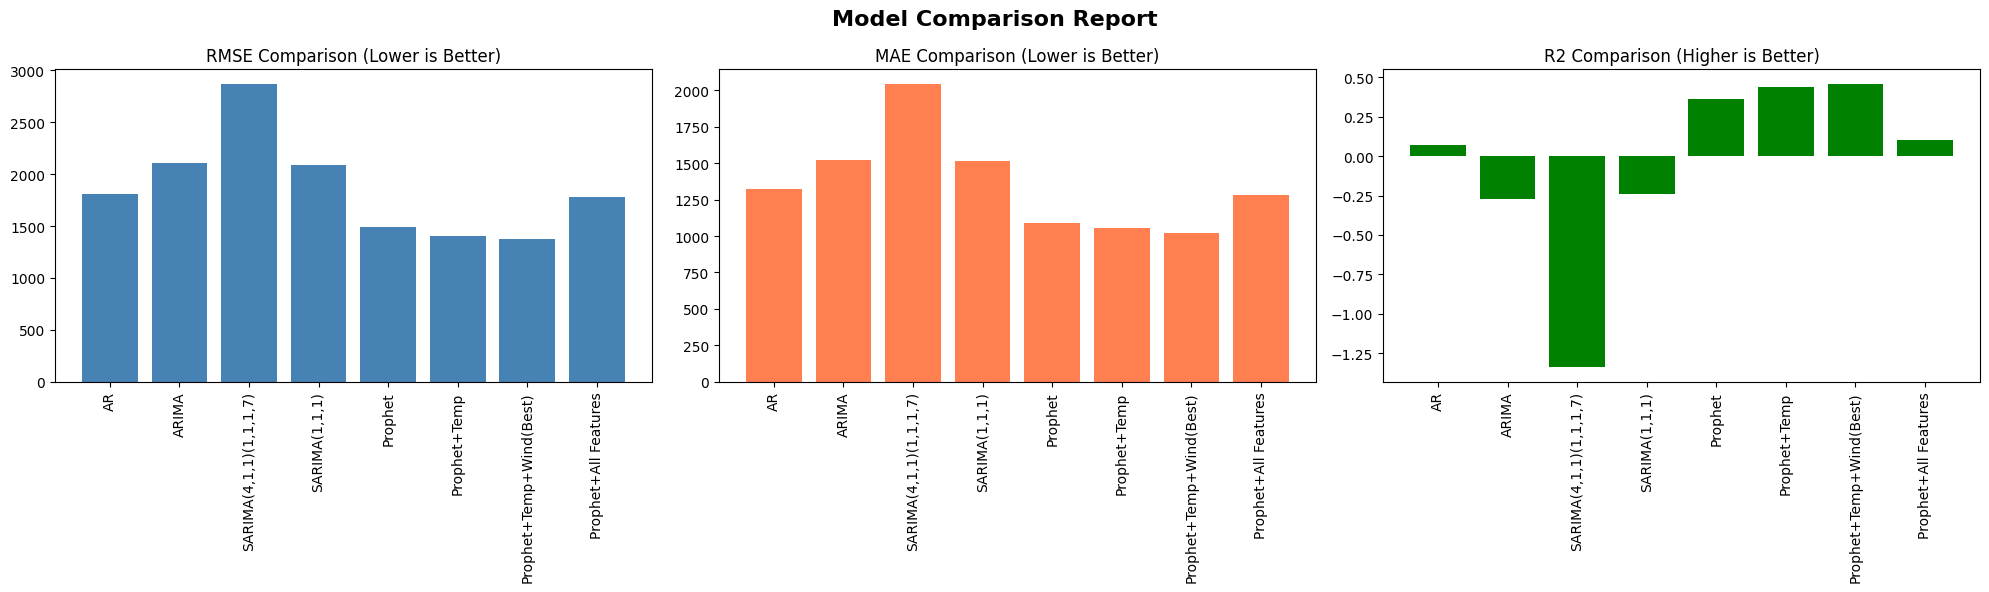

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20,6))

axes[0].bar(comparison['Model'], comparison['RMSE'], color='steelblue')
axes[0].set_title("RMSE Comparison (Lower is Better)")
axes[0].tick_params(axis='x', rotation=90)

axes[1].bar(comparison['Model'], comparison['MAE'], color='coral')
axes[1].set_title("MAE Comparison (Lower is Better)")
axes[1].tick_params(axis='x', rotation=90)

axes[2].bar(comparison['Model'], comparison['R2'], color='green')
axes[2].set_title("R2 Comparison (Higher is Better)")
axes[2].tick_params(axis='x', rotation=90)

plt.suptitle("Model Comparison Report", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
print("=" * 45)
print("         AIC Comparison Report")
print("=" * 45)
print(f"AR                        : {round(ar_model_fit.aic, 2)}")
print(f"ARIMA                     : {round(arima_model.aic, 2)}")
print(f"SARIMA(4,1,1)(1,1,1,7)    : {round(sarima_model.aic, 2)}")
print(f"SARIMA(1,1,1)             : {round(sarima_model2.aic, 2)}")
print(f"Prophet                   : Not applicable — ML based")
print(f"Prophet+Temp              : Not applicable — ML based")
print(f"Prophet+Temp+Wind(Best)   : Not applicable — ML based")
print(f"Prophet+All Features      : Not applicable — ML based")
print("=" * 45)
print("Note: Lower AIC = Better statistical fit")
print("      AIC only applies to statistical models")

         AIC Comparison Report
AR                        : 9303.13
ARIMA                     : 9521.33
SARIMA(4,1,1)(1,1,1,7)    : 9430.79
SARIMA(1,1,1)             : 9520.56
Prophet                   : Not applicable — ML based
Prophet+Temp              : Not applicable — ML based
Prophet+Temp+Wind(Best)   : Not applicable — ML based
Prophet+All Features      : Not applicable — ML based
Note: Lower AIC = Better statistical fit
      AIC only applies to statistical models


***AIC Interpretation:***

- **AR (9303.13)** has the lowest AIC — most statistically efficient among classical models
- Interesting finding: AR wins on AIC but Prophet wins on prediction accuracy (RMSE/R²)
- AIC measures model simplicity vs fit — it does not measure real-world predictive accuracy
- For production deployment → **Prophet recommended** (better actual predictions on unseen data)

# 11. Challenges Faced & Solutions


### Challenge 1 — Data Selection

*    **Problem**   : Choosing between day.csv and hour.csv
*    **Technique** : Used day.csv
*    **Reason**    : Problem focuses on daily bike rental prediction


### Challenge 2 — Target Leakage

*    **Problem**   : casual and registered columns present in dataset
*    **Technique** : Dropped both columns
*    **Reason**    : They are direct sub-components of the target variable cnt


### Challenge 3 — Nonstationarity

*    **Problem**   : Time series was non-stationary
*    **Technique** : Applied 1st order differencing
*    **Reason**    : ADF test confirmed stationarity after differencing (d = 1)


### Challenge 4 — Outliers in Windspeed

*    **Problem**   : Outliers detected in windspeed column
*    **Technique** : Applied IQR capping for windspeed
*    **Reason**    : Outliers in holiday and hum retained as they
                    represent genuine real-world behavior


### Challenge 5 — ACF/PACF Interpretation

*    **Problem**   : Needed to identify ARIMA order parameters
*    **Technique** : Used ACF and PACF plots
*    **Reason**    : ACF estimated q = 1, PACF estimated p = 4,
                    differencing determined d = 1


### Challenge 6 — SARIMA Poor Performance

*    **Problem**   : SARIMA underperformed on this dataset
*    **Technique** : Switched to Prophet
*    **Reason**    : SARIMA needs larger datasets with stronger seasonal cycles.
                    This dataset has only 731 daily observations


### Challenge 7 — Small Dataset

*    **Problem**   : Limited data restricted complex model learning
*    **Technique** : Used Prophet
*    **Reason**    : Prophet handles small-scale seasonal forecasting
                    more effectively


### Challenge 8 — Feature Selection for Prophet

*    **Problem**   : Needed to select external regressors
*    **Technique** : Selected based on correlation analysis
*    **Reason**    : Retained temp (0.63) and windspeed (-0.23)
                    as the two strongest predictors


### Challenge 9 — Overfitting with Many Features

*    **Problem**   : Including all 6 external features gave R² ≈ 0.10
*    **Technique** : Reduced to 2 most relevant features
*    **Reason**    : Fewer, stronger features improve generalization
                    and reduce noise

# 12. 🏆 Conclusion & Model Saving

## Final Results Summary

| Model | RMSE | MAE | R² |
|-------|------|-----|----|
| AR | 1806.04 | 1322.05 | 0.07 |
| ARIMA | 2112.30 | 1522.11 | -0.27 |
| SARIMA(4,1,1)(1,1,1,7) | 2867.74 | 2042.82 | -1.34 |
| SARIMA(1,1,1) | 2091.37 | 1514.71 | -0.24 |
| Prophet (basic) | 1495.69 | 1088.27 | 0.36 |
| Prophet + Temp | 1405.34 | 1055.06 | 0.44 |
| **Prophet + Temp + Wind** | **1371.53** | **1023.93** | **0.46** |
| Prophet + All Features | 1779.54 | 1278.97 | 0.10 |

## ✅ Best Model → Prophet + Temp + Windspeed

- ✅ Lowest RMSE → 1371.53
- ✅ Lowest MAE → 1023.93
- ✅ Highest R² → 0.46
- ✅ Automatically handles daily, weekly and yearly seasonality
- ✅ Only needs `temp` and `windspeed` as real-world inputs — easy to collect from weather APIs
- ✅ Adding too many features hurt performance — feature selection by correlation was critical

## 💡 Key Takeaways & Business Insights

**If deployed in a bike-sharing operations system:**

- This model can forecast demand 7–30 days ahead using just temperature and wind forecasts
- Operations team can pre-position bikes at high-demand stations before peak days
- Maintenance scheduling can be optimized around predicted low-demand periods
- Most important real-world inputs: `temp` and `windspeed` — both available from weather APIs

**⚠️ Limitations:**

- Dataset limited to 731 days (2011–2012) — more data would significantly improve all models
- External factors like city events, promotions, infrastructure changes not captured
- Trained on Washington D.C. data — may not generalize to other cities without retraining
- R² of 0.46 is acceptable for 2-year time series, but 5+ years would push it higher

**🚀 Future Improvements:**

- Collect 5+ years of data for better seasonal learning in SARIMA
- Add holiday effects explicitly to Prophet using `add_country_holidays()`
- Try LSTM/GRU deep learning for sequential pattern learning
- Deploy as interactive Streamlit web app for real-time forecasting

## 💾 Model Saving

We save the best model using pickle so it can be reused for deployment — without needing to retrain from scratch. We save the model as a **bundle** including required feature names and performance metrics for easy reference.

In [ ]:
import pickle

# Save the best model + metadata together as a bundle
model_bundle = {
    'model': prophet_model4,          # best performing model
    'model_name': 'Prophet + Temp + Windspeed',
    'required_features': ['temp', 'windspeed'],  # inputs needed for prediction
    'metrics': {'RMSE': 1371.53, 'MAE': 1023.93, 'R2': 0.46}
}

with open('bike_rental_model.pkl', 'wb') as f:
    pickle.dump(model_bundle, f)

print('Model saved as bike_rental_model.pkl')
print('Bundle contains: model, model name, required features, metrics')

Model saved as bike_rental_model.pkl
Bundle contains: model, model name, required features, metrics


In [ ]:
# How to load and use for future predictions
with open('bike_rental_model.pkl', 'rb') as f:
    bundle = pickle.load(f)

# Example: predict next 7 days
future_dates = pd.date_range(start='2013-01-01', periods=7, freq='D')
future_df = pd.DataFrame({
    'ds': future_dates,
    'temp': [0.3, 0.35, 0.4, 0.38, 0.42, 0.45, 0.5],       # example normalized temp
    'windspeed': [0.2, 0.18, 0.22, 0.25, 0.19, 0.21, 0.23]  # example normalized windspeed
})

future_forecast = bundle['model'].predict(future_df)
print("7-Day Forecast:")
print(future_forecast[['ds','yhat','yhat_lower','yhat_upper']].to_string(index=False))

7-Day Forecast:
        ds        yhat  yhat_lower  yhat_upper
2013-01-01 4661.363866 3744.852524 5650.985149
2013-01-02 4785.709006 3783.535294 5835.481773
2013-01-03 5106.853004 4069.504794 6059.781233
2013-01-04 5048.881801 4011.754199 6059.082454
2013-01-05 5333.512953 4337.622118 6332.613010
2013-01-06 5238.701798 4226.445781 6245.912742
2013-01-07 5453.283761 4469.660177 6414.260430


In [ ]:
from google.colab import files
files.download('bike_rental_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>